## 匯入資料
匯入資料＋將每日價格轉為日報酬

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/DCOILWTICO.csv")

df["observation_date"] = pd.to_datetime(
    df["observation_date"]
)

# 移除price缺失值
price = (
    df.loc[
        df["DCOILWTICO"].notna(),
        ["observation_date", "DCOILWTICO"]
    ]
    .set_index("observation_date")["DCOILWTICO"]
)

# Return
return_series = price.pct_change().dropna()

# Log Return
log_return_series = np.log(
    price / price.shift(1)
).dropna()

#合併return和log_return
return_df = pd.DataFrame({
    "DCOILWTICO": price,
    "return": return_series,
    "log_return": log_return_series
})

/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## ADF檢定(Augmented Dickey-Fuller Test)
單根檢定：Price、Return 是否適合拿來做時間序列模型？
- **H₀：** τ＝0(序列有單根，資料是非定態的)
- **H₁：** τ<0(序列沒有單根，資料是定態的)

In [2]:
#使用ADF檢定price資料是否定態
from statsmodels.tsa.stattools import adfuller

adf_price = adfuller(price)

print("ADF Statistic:", adf_price[0])
print("p-value:", adf_price[1])

ADF Statistic: -2.5349179235319212
p-value: 0.10720788516679897


/var/folders/vw/tk3fr7d56tx7wvkmb9krpxqc0000gn/T/ipykernel_38844/2661067863.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_price = adfuller(price)


In [3]:
#使用ADF檢定return資料是否定態
adf_result = adfuller(return_series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -19.00676988730095
p-value: 0.0


/var/folders/vw/tk3fr7d56tx7wvkmb9krpxqc0000gn/T/ipykernel_38844/1921095426.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(return_series)


## Retrun敘述性統計

In [4]:
#查看資料前10筆
return_df.head(10)

,DCOILWTICO,return,log_return
observation_date,,,
1986-01-02,25.56,NaN,NaN
1986-01-03,26.00,0.017214,0.017068
1986-01-06,26.53,0.020385,0.020180
1986-01-07,25.85,-0.025631,-0.025966
1986-01-08,25.87,0.000774,0.000773
1986-01-09,26.03,0.006185,0.006166
1986-01-10,25.65,-0.014599,-0.014706
1986-01-13,25.08,-0.022222,-0.022473
1986-01-14,24.97,-0.004386,-0.004396


In [5]:
# Return 敘述性統計
return_series.describe()

count    10225.000000
mean         0.000138
std          0.042177
min         -3.019661
25%         -0.012100
50%          0.000747
75%          0.013274
max          0.530864
Name: DCOILWTICO, dtype: float64

## Return 是否符合常態分布？

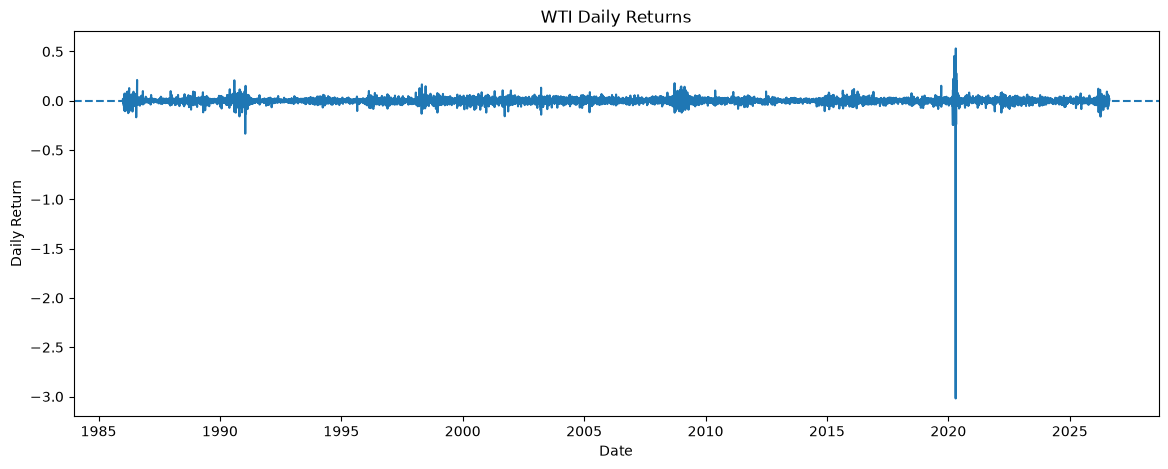

In [6]:
# Daily Return Time Series

plt.figure(figsize=(14, 5))

plt.plot(
    return_series.index,
    return_series
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("WTI Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

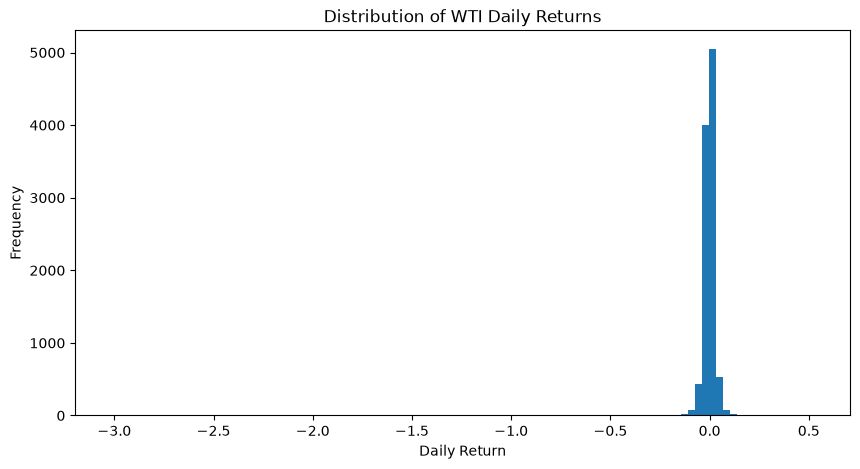

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(
    return_series,
    bins=100
)

plt.title("Distribution of WTI Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

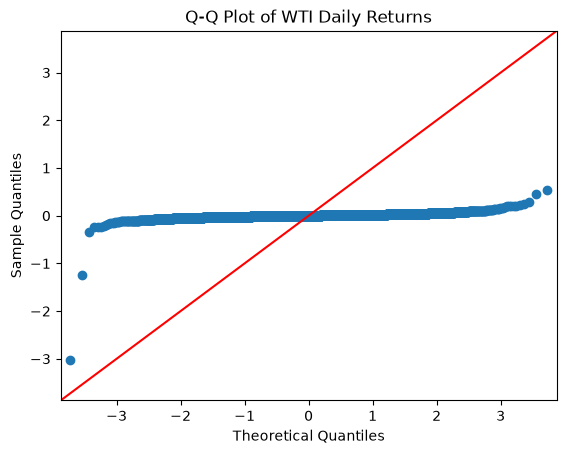

In [8]:
import statsmodels.api as sm

sm.qqplot(
    return_series,
    line="45"
)

plt.title("Q-Q Plot of WTI Daily Returns")
plt.show()

In [ ]:

print("Skewness:", return_series.skew())
print("Kurtosis:", return_series.kurtosis())


Original:
Skewness: -38.09573253945106
Kurtosis: 2648.328833972289


## 波動分析

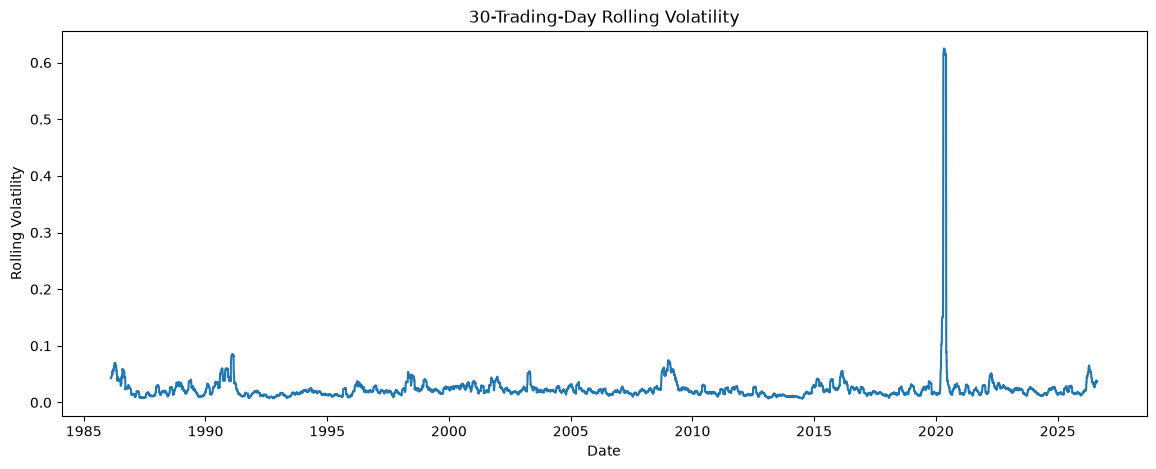

In [18]:
# 計算 30-day Rolling Volatility
rolling_volatility_30 = return_series.rolling(window=30).std()

#畫 Rolling Volatility
plt.figure(figsize=(14, 5))

plt.plot(
    rolling_volatility_30.index,
    rolling_volatility_30
)

plt.title("30-Trading-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")

plt.show()

## 自我相關性（Autocorrelation）分析

#### 自我相關函數(autocorrelation function, ACF)

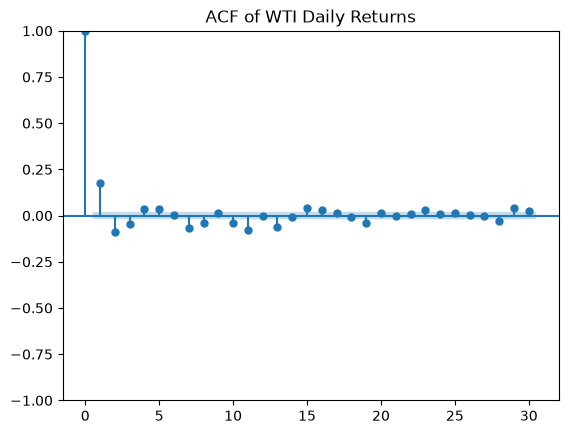

In [ ]:
# Return的ACF
# 自我相關函數(autocorrelation function, ACF)

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    return_series,
    lags=30
)

plt.title("ACF of WTI Daily Returns")
plt.show()

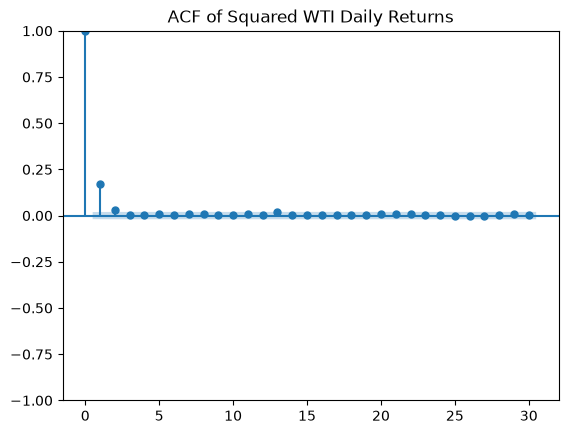

In [ ]:
# Squared Return的ACF
# 自我相關函數(autocorrelation function, ACF)

plot_acf(
    return_series** 2,
    lags=30
)

plt.title("ACF of Squared WTI Daily Returns")
plt.show()

#### 偏自我相關函數 (partial autocorrelation function, PACF)

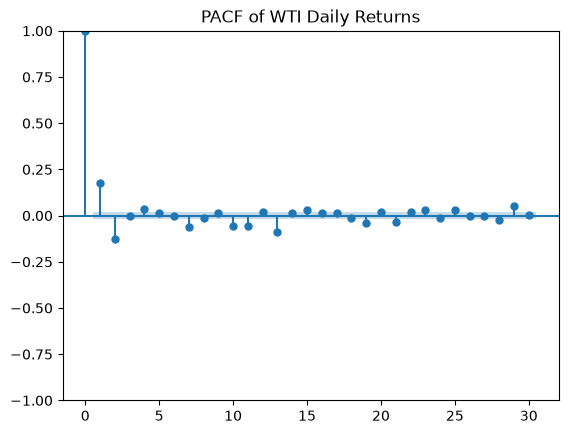

In [15]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plot_pacf(
    return_series,
    lags=30
)

plt.title("PACF of WTI Daily Returns")
plt.show()

#### Ljung-Box Ｑ Test
- **H₀：** 殘差為白噪音
- **H₁：** 殘差不為白噪音

In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(
    return_series,
    lags=[10, 20],
    return_df=True
)

,lb_stat,lb_pvalue
10,525.776180,1.363511e-106
20,677.628284,1.192436e-130


In [17]:
#Squared returns 是否存在 autocorrelation？
#Ljung–Box Test on Squared Returns

acorr_ljungbox(
    return_series ** 2,
    lags=[10, 20],
    return_df=True
)



,lb_stat,lb_pvalue
10,305.305973,1.174125e-59
20,312.640972,2.102959e-54
